In [1]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, StackingClassifier,  HistGradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import RandomizedSearchCV
import warnings 
import missingno as msno
import scipy.stats as stats
from scipy.stats import chi2_contingency
import keras
from keras.models import Sequential
from keras.models import Model
from keras.layers import Input, Dense, Embedding, Flatten, Concatenate, Dropout
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection  import StratifiedKFold, cross_validate
from sklearn.impute import SimpleImputer
warnings.filterwarnings('ignore')
# 0) Imports
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PowerTransformer, RobustScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate




2025-04-25 14:08:17.348201: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-25 14:08:17.351318: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 14:08:17.355400: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-25 14:08:17.365675: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745590097.381959 3420931 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745590097.38

In [2]:
features = pd.read_csv('train_values.csv')
labels = pd.read_csv('train_labels.csv')

df = pd.concat([features, labels['damage_grade']], axis=1)
df.head()

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other,damage_grade
0,802906,6,487,12198,2,30,6,5,t,r,...,0,0,0,0,0,0,0,0,0,3
1,28830,8,900,2812,2,10,8,7,o,r,...,0,0,0,0,0,0,0,0,0,2
2,94947,21,363,8973,2,10,5,5,t,r,...,0,0,0,0,0,0,0,0,0,3
3,590882,22,418,10694,2,10,6,5,t,r,...,0,0,0,0,0,0,0,0,0,2
4,201944,11,131,1488,3,30,8,9,t,r,...,0,0,0,0,0,0,0,0,0,3


In [3]:
# duplicates
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# if >0, optionally drop them:
df = df.drop_duplicates()

# look for impossible values, e.g. negative counts
print(df[df['count_families'] < 0])


Duplicate rows: 0
Empty DataFrame
Columns: [building_id, geo_level_1_id, geo_level_2_id, geo_level_3_id, count_floors_pre_eq, age, area_percentage, height_percentage, land_surface_condition, foundation_type, roof_type, ground_floor_type, other_floor_type, position, plan_configuration, has_superstructure_adobe_mud, has_superstructure_mud_mortar_stone, has_superstructure_stone_flag, has_superstructure_cement_mortar_stone, has_superstructure_mud_mortar_brick, has_superstructure_cement_mortar_brick, has_superstructure_timber, has_superstructure_bamboo, has_superstructure_rc_non_engineered, has_superstructure_rc_engineered, has_superstructure_other, legal_ownership_status, count_families, has_secondary_use, has_secondary_use_agriculture, has_secondary_use_hotel, has_secondary_use_rental, has_secondary_use_institution, has_secondary_use_school, has_secondary_use_industry, has_secondary_use_health_post, has_secondary_use_gov_office, has_secondary_use_use_police, has_secondary_use_other, damag

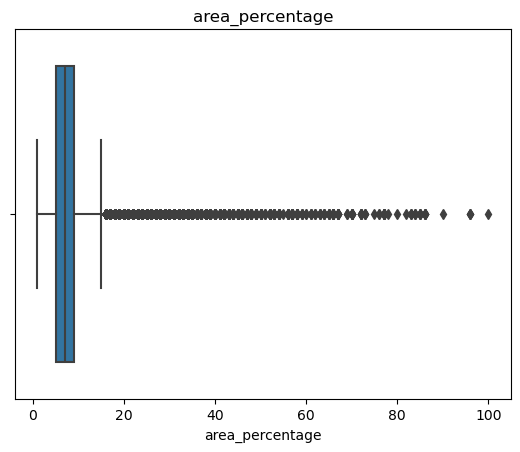

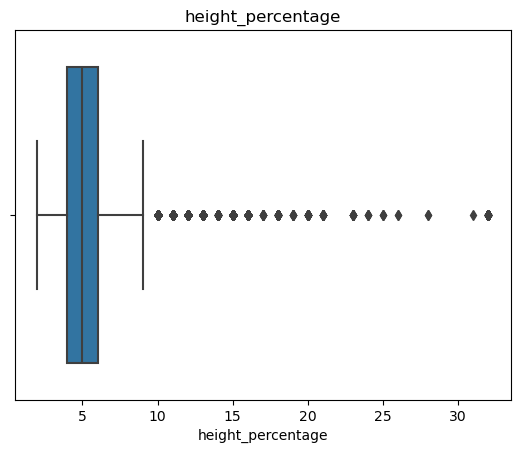

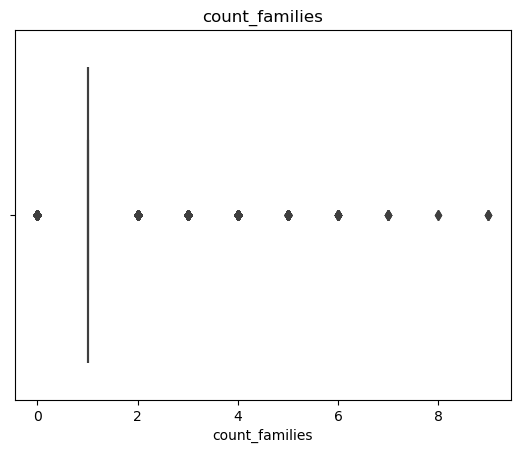

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# boxplot on key numeric features
for col in ['area_percentage','height_percentage','count_families']:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


In [5]:
print(df['area_percentage'].describe())
print(df['height_percentage'].describe())
# Optional: list the top 10 rows
print(df.sort_values('area_percentage', ascending=False).head(10))


count    260601.000000
mean          8.018051
std           4.392231
min           1.000000
25%           5.000000
50%           7.000000
75%           9.000000
max         100.000000
Name: area_percentage, dtype: float64
count    260601.000000
mean          5.434365
std           1.918418
min           2.000000
25%           4.000000
50%           5.000000
75%           6.000000
max          32.000000
Name: height_percentage, dtype: float64
        building_id  geo_level_1_id  geo_level_2_id  geo_level_3_id  \
4790         361707               3             175            6924   
127007       220534               6            1082           11745   
200707      1021705              26              39            9897   
204527       661586               7              49            7507   
149199       764043              21             929             917   
56752        645420              26              39            9897   
161256       392807              26             886      

In [6]:
#categorical
for col in df.select_dtypes('object'):
    print(col, df[col].value_counts())

land_surface_condition land_surface_condition
t    216757
n     35528
o      8316
Name: count, dtype: int64
foundation_type foundation_type
r    219196
w     15118
u     14260
i     10579
h      1448
Name: count, dtype: int64
roof_type roof_type
n    182842
q     61576
x     16183
Name: count, dtype: int64
ground_floor_type ground_floor_type
f    209619
x     24877
v     24593
z      1004
m       508
Name: count, dtype: int64
other_floor_type other_floor_type
q    165282
x     43448
j     39843
s     12028
Name: count, dtype: int64
position position
s    202090
t     42896
j     13282
o      2333
Name: count, dtype: int64
plan_configuration plan_configuration
d    250072
q      5692
u      3649
s       346
c       325
a       252
o       159
m        46
n        38
f        22
Name: count, dtype: int64
legal_ownership_status legal_ownership_status
v    250939
a      5512
w      2677
r      1473
Name: count, dtype: int64


In [7]:
# count missing per column
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

# percent missing
percent_missing = 100 * missing / len(df)
print(percent_missing[percent_missing > 0])

Series([], dtype: int64)
Series([], dtype: float64)


In [8]:
print(df.isnull().sum())

building_id                               0
geo_level_1_id                            0
geo_level_2_id                            0
geo_level_3_id                            0
count_floors_pre_eq                       0
age                                       0
area_percentage                           0
height_percentage                         0
land_surface_condition                    0
foundation_type                           0
roof_type                                 0
ground_floor_type                         0
other_floor_type                          0
position                                  0
plan_configuration                        0
has_superstructure_adobe_mud              0
has_superstructure_mud_mortar_stone       0
has_superstructure_stone_flag             0
has_superstructure_cement_mortar_stone    0
has_superstructure_mud_mortar_brick       0
has_superstructure_cement_mortar_brick    0
has_superstructure_timber                 0
has_superstructure_bamboo       

In [9]:
#Splitting the data between training and testing
X_train, X_val, y_train, y_val = train_test_split(df.drop('damage_grade', axis=1), df['damage_grade'], random_state=20, shuffle=True, test_size=0.01)

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(257994, 39)
(2607, 39)
(257994,)
(2607,)


In [10]:
column_names = list(df.drop('damage_grade', axis=1).columns)
multi_class_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()>2]
binary_columns = [col for col in column_names if df[col].dtype=='object' and df[col].nunique()==2]
num_columns = [col for col in column_names if df[col].dtype!='object']
print(f"Multi Class columns: {multi_class_columns}")
print(f"Binary columns: {binary_columns}")
print(f"Numerical columns: {num_columns}")

Multi Class columns: ['land_surface_condition', 'foundation_type', 'roof_type', 'ground_floor_type', 'other_floor_type', 'position', 'plan_configuration', 'legal_ownership_status']
Binary columns: []
Numerical columns: ['building_id', 'geo_level_1_id', 'geo_level_2_id', 'geo_level_3_id', 'count_floors_pre_eq', 'age', 'area_percentage', 'height_percentage', 'has_superstructure_adobe_mud', 'has_superstructure_mud_mortar_stone', 'has_superstructure_stone_flag', 'has_superstructure_cement_mortar_stone', 'has_superstructure_mud_mortar_brick', 'has_superstructure_cement_mortar_brick', 'has_superstructure_timber', 'has_superstructure_bamboo', 'has_superstructure_rc_non_engineered', 'has_superstructure_rc_engineered', 'has_superstructure_other', 'count_families', 'has_secondary_use', 'has_secondary_use_agriculture', 'has_secondary_use_hotel', 'has_secondary_use_rental', 'has_secondary_use_institution', 'has_secondary_use_school', 'has_secondary_use_industry', 'has_secondary_use_health_post', '

In [11]:
def cap_area_height(X, lower=0.01, upper=0.99):
    X = X.copy()
    # get the cutoffs once
    qs = X[['area_percentage','height_percentage']].quantile([lower, upper])
    lo = qs.loc[lower]
    hi = qs.loc[upper]
    
    # clip each column
    for col in ['area_percentage','height_percentage']:
        X[col] = X[col].clip(lo[col], hi[col])
    return X

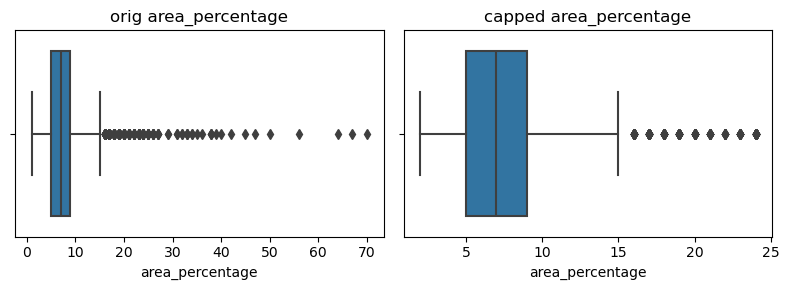

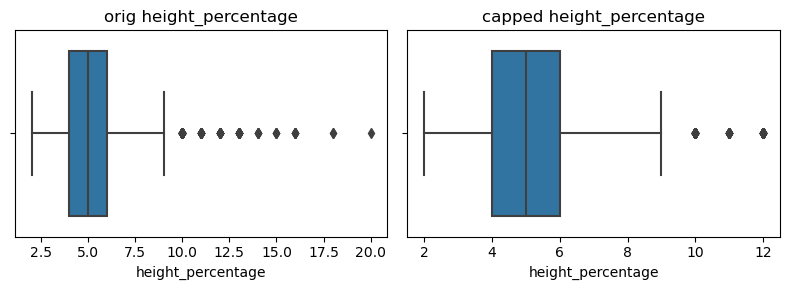

In [12]:
# apply to a small sample
sample = df[['area_percentage','height_percentage']].sample(5000, random_state=0)
capped = cap_area_height(sample)

import matplotlib.pyplot as plt, seaborn as sns

for col in ['area_percentage','height_percentage']:
    fig, axes = plt.subplots(1,2, figsize=(8,3))
    sns.boxplot(x=sample[col], ax=axes[0]).set_title(f"orig {col}")
    sns.boxplot(x=capped[col], ax=axes[1]).set_title(f"capped {col}")
    plt.tight_layout()
    plt.show()


In [13]:
models = [
    RandomForestClassifier(random_state=42),
]

In [14]:

# 1) Define our custom capper
class OutlierCapper(BaseEstimator, TransformerMixin):
    def __init__(self, cols, lower=0.01, upper=0.99):
        self.cols = cols            # e.g. ['area_percentage','height_percentage']
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        # X is a numpy array of shape (n_samples, n_num_cols)
        # find each target col’s integer index
        self.col_indices_ = [num_columns.index(c) for c in self.cols]
        # extract the sub‐array of just those columns
        sub = X[:, self.col_indices_]
        # compute quantiles along axis=0 → shape (2, len(cols))
        q = np.quantile(sub, [self.lower, self.upper], axis=0)
        self.lo_, self.hi_ = q[0], q[1]
        return self

    def transform(self, X):
        X = X.copy()
        # clip each specified column by its learned lo_/hi_
        for idx, lo, hi in zip(self.col_indices_, self.lo_, self.hi_):
            X[:, idx] = np.clip(X[:, idx], lo, hi)
        return X

In [15]:
# 2) Numeric pipeline
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('cap',    OutlierCapper(cols=['area_percentage','height_percentage'],
                             lower=0.01, upper=0.99)),
    ('power',  PowerTransformer(method='yeo-johnson')),
    ('scale',  RobustScaler()),
])


In [16]:
# 3) Categorical pipeline
cat_pipeline = Pipeline([
    # 3a) Impute missing categories into a "MISSING" bucket
    ('impute', SimpleImputer(strategy='constant', fill_value='MISSING')),
    # 3b) One-hot encode all levels, ignore unseen at predict time
    ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

In [17]:
# 4) Assemble ColumnTransformer
preprocessor = ColumnTransformer([
    # apply numeric_pipeline to all numeric features
    ('num', numeric_pipeline, num_columns),
    # apply cat_pipeline to all categorical features
    ('cat', cat_pipeline,   multi_class_columns + binary_columns),
])


In [18]:
# 5) Pipeline factory
def get_pipeline(model):
    """
    Returns a full Pipeline that:
     - applies preprocessor to DataFrame
     - then fits the model
    """
    return Pipeline([
        ('preprocessor', preprocessor),
        ('clf',        model)
    ])

In [19]:
# 7) Quick Stratified 3-fold CV to compare
cv      = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv

StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

In [20]:
scoring = {
    'accuracy':   'accuracy',
    'weighted_f1':'f1_weighted'
}
records = []

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
import numpy as np

import warnings

# ignore only that logistic‐regression warning
warnings.filterwarnings(
    "ignore",
    message=".*l1_ratio parameter is only used when penalty is 'elasticnet'.*",
    category=UserWarning
)

In [22]:
# 1) Build your full pipeline factory
def get_pipeline(model):
    return Pipeline([
        ('pre', preprocessor),
        ('clf', model)
    ])

# 2) Define the LogisticRegression and its hyperparameter space
logreg = LogisticRegression(max_iter=500, class_weight='balanced', random_state=42)

param_dist = {
    'clf__penalty': ['l1', 'l2', 'elasticnet', 'none'],
    'clf__C': np.logspace(-4, 4, 20),
    'clf__solver': ['saga'],  # saga supports all penalties
    'clf__l1_ratio': [0, .25, .5, .75, 1]  # only used if penalty='elasticnet'
}

# 3) Wrap in RandomizedSearchCV
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator   = get_pipeline(logreg),
    param_distributions = param_dist,
    n_iter      = 15,
    cv          = cv_inner,
    scoring     = 'f1_weighted',
    verbose     = 2,
    n_jobs      = -1,
    random_state=42
)

# 4) Evaluate with an outer cross‐validation to get an honest estimate
cv_outer = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
nested_scores = cross_validate(
    random_search,
    X_train,
    y_train,
    cv=cv_outer,
    scoring=['accuracy', 'f1_weighted'],
    return_train_score=False,
    return_estimator=True 
)

print("Nested CV results:")
print(f"Accuracy:      {nested_scores['test_accuracy'].mean():.3f} ± {nested_scores['test_accuracy'].std():.3f}")
print(f"Weighted F1:   {nested_scores['test_f1_weighted'].mean():.3f} ± {nested_scores['test_f1_weighted'].std():.3f}")


Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175:

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175:

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175:

Nested CV results:
Accuracy:      0.511 ± 0.001
Weighted F1:   0.506 ± 0.002


In [23]:
# 7) Look at which hyperparameters won in each outer fold:
for i, est in enumerate(nested_scores['estimator'], start=1):
    print(f" Fold {i} winner:  ")
    print("   hyperparams:", est.best_params_)
    print("   inner F1   :", est.best_score_)
    print()

# 8) Finally: tune on all the data to get one global best
random_search.fit(X_train, y_train)
print("Global best weighted-F1:", random_search.best_score_)
print("Global best hyperparameters:", random_search.best_params_)

 Fold 1 winner:  
   hyperparams: {'clf__solver': 'saga', 'clf__penalty': 'elasticnet', 'clf__l1_ratio': 0.5, 'clf__C': 1.623776739188721}
   inner F1   : 0.5065473863880093

 Fold 2 winner:  
   hyperparams: {'clf__solver': 'saga', 'clf__penalty': 'l1', 'clf__l1_ratio': 0, 'clf__C': 78.47599703514607}
   inner F1   : 0.5039320168070399

 Fold 3 winner:  
   hyperparams: {'clf__solver': 'saga', 'clf__penalty': 'l1', 'clf__l1_ratio': 0, 'clf__C': 78.47599703514607}
   inner F1   : 0.5055440638672563

Fitting 3 folds for each of 15 candidates, totalling 45 fits


/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175:

[CV] END clf__C=1.623776739188721, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time= 1.6min
[CV] END clf__C=3792.690190732246, clf__l1_ratio=0, clf__penalty=l2, clf__solver=saga; total time= 1.6min
[CV] END clf__C=1.623776739188721, clf__l1_ratio=0.5, clf__penalty=elasticnet, clf__solver=saga; total time= 2.0min
[CV] END clf__C=0.0018329807108324356, clf__l1_ratio=0.75, clf__penalty=l1, clf__solver=saga; total time=  21.1s
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time=  12.7s
[CV] END clf__C=545.5594781168514, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time= 1.5min
[CV] END clf__C=3792.690190732246, clf__l1_ratio=0, clf__penalty=l2, clf__solver=saga; total time= 1.5min
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time=  23.3s
[CV] END clf__C=545.5594781168514, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time= 2.4min
[CV] END 

In [24]:
df_test = pd.read_csv('test_values.csv')

In [25]:
df_test

,building_id,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,...,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,300051,17,596,11307,3,20,7,6,t,r,...,0,0,0,0,0,0,0,0,0,0
1,99355,6,141,11987,2,25,13,5,t,r,...,1,0,0,0,0,0,0,0,0,0
2,890251,22,19,10044,2,5,4,5,t,r,...,0,0,0,0,0,0,0,0,0,0
3,745817,26,39,633,1,0,19,3,t,r,...,0,0,1,0,0,0,0,0,0,0
4,421793,17,289,7970,3,15,8,7,t,r,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86863,310028,4,605,3623,3,70,20,6,t,r,...,1,0,0,0,0,0,0,0,0,0
86864,663567,10,1407,11907,3,25,6,7,n,r,...,0,0,0,0,0,0,0,0,0,0
86865,1049160,22,1136,7712,1,50,3,3,t,r,...,0,0,0,0,0,0,0,0,0,0
86866,442785,6,1041,912,2,5,9,5,t,r,...,0,0,0,0,0,0,0,0,0,0


In [26]:
ids     = df_test['building_id'].values
ids

array([ 300051,   99355,  890251, ..., 1049160,  442785,  501372])

In [27]:
X_test  = df_test

In [28]:
# 2) Grab the final, refit pipeline
best_rf_pipe = random_search.best_estimator_

# 3) (Optional) Retrain explicitly on full data—though best_estimator_ is already fitted:
best_rf_pipe.fit(X_train, y_train)

# 4) Generate predictions on your test set
preds = best_rf_pipe.predict(X_test)

# 5) Save them out
import pandas as pd

pd.DataFrame({
    'building_id': ids,
    'damage_grade': preds
}).to_csv('Logistic_tuned_submission.csv', index=False)

[CV] END clf__C=1.623776739188721, clf__l1_ratio=0.5, clf__penalty=elasticnet, clf__solver=saga; total time= 2.1min
[CV] END clf__C=0.033598182862837805, clf__l1_ratio=0.75, clf__penalty=l1, clf__solver=saga; total time= 1.8min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time=  37.8s
[CV] END clf__C=545.5594781168514, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time= 1.5min
[CV] END clf__C=78.47599703514607, clf__l1_ratio=0, clf__penalty=l1, clf__solver=saga; total time= 2.1min
[CV] END clf__C=1.623776739188721, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time= 2.4min
[CV] END clf__C=9.999999999999999e-05, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time=  11.7s
[CV] END clf__C=3792.690190732246, clf__l1_ratio=0, clf__penalty=l2, clf__solver=saga; total time= 2.3min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time=  44.7s
[CV] END

In [32]:
# Assume `best_model` is your fitted pipeline (after search.fit)
train_pred = random_search.predict(X_train)
val_pred = random_search.predict(X_val)

from sklearn.metrics import accuracy_score, f1_score
print("Train acc:", accuracy_score(y_train, train_pred))
print("Valid acc:", accuracy_score(y_val, val_pred))
print("Train F1:", f1_score(y_train, train_pred, average='weighted'))
print("Valid F1:", f1_score(y_val, val_pred, average='weighted'))


Train acc: 0.510663038675318
Valid acc: 0.5136171845032604
Train F1: 0.5058140757112823
Valid F1: 0.5093354504808553


/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175:

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time=  39.5s
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time=  44.7s
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time=  45.1s
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time= 1.6min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time= 2.1min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 2.2min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 2.5min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=elasticnet, clf__solver=saga; total time= 1.7min
[CV] END clf__C=1.62377673918872

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter 

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time=  38.3s
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time=  44.8s
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time= 1.6min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 2.3min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time= 2.4min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 3.2min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=elasticnet, clf__solver=saga; total time= 1.6min
[CV] END clf__C=1.623776739188721, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time= 3.3min
[CV] END clf__C=0.0002636650898730358

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1175: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter 

...

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV] END clf__C=1.623776739188721, clf__l1_ratio=0.5, clf__penalty=elasticnet, clf__solver=saga; total time= 4.2min
[CV] END clf__C=78.47599703514607, clf__l1_ratio=0, clf__penalty=l1, clf__solver=saga; total time= 4.2min
[CV] END clf__C=0.0018329807108324356, clf__l1_ratio=0.75, clf__penalty=l1, clf__solver=saga; total time=  28.2s
[CV] END clf__C=0.0018329807108324356, clf__l1_ratio=0.75, clf__penalty=l1, clf__solver=saga; total time=  31.1s
[CV] END clf__C=1.623776739188721, clf__l1_ratio=0.5, clf__penalty=elasticnet, clf__solver=saga; total time= 4.6min
[CV] END clf__C=0.0018329807108324356, clf__l1_ratio=0.75, clf__penalty=l1, clf__solver=saga; total time=  33.2s
[CV] END clf__C=545.5594781168514, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time= 5.2min
[CV] END clf__C=0.033598182862837805, clf__l1_ratio=0.25, clf__penalty=elasticnet, clf__solver=saga; total time= 3.2min
[CV] END clf__C=3792.690190732246, clf__l1_ratio=0, clf__penalty=l2, clf__solver=saga; total ti

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 5.2min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time= 7.9min
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 8.8min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time=10.8min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=elasticnet, clf__solver=saga; total time= 4.7min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time=13.6min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=elasticnet, clf__solver=saga; total time= 5.5min
[CV] END clf__C=545.5594781168514, clf__l1_ratio=0.5, clf__penalty=l2, clf__solver=saga; total time=19.9min
[CV] END clf__C=0.00483293023

/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/apps/software/lang/Anaconda3/2024.02-1/lib/python3.11/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


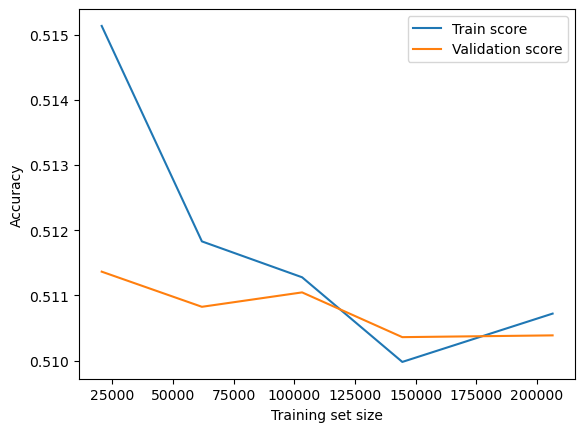

In [34]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes, train_scores, val_scores = learning_curve(
    random_search, X_train, y_train,
    train_sizes=[0.1,0.3,0.5,0.7,1.0],
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label='Train score')
plt.plot(train_sizes, val_mean,   label='Validation score')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [35]:
print("Outer CV acc scores:", nested_results['test_accuracy'])
print("Mean ± SD:", nested_results['test_accuracy'].mean(), "+/-", nested_results['test_accuracy'].std())

NameError: name 'nested_results' is not defined

Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 3.4min
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 6.0min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time= 7.0min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time= 8.2min
[CV] END clf__C=0.0002636650898730358, clf__l1_ratio=0.75, clf__penalty=l2, clf__solver=saga; total time= 8.5min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.25, clf__penalty=l1, clf__solver=saga; total time=10.1min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=elasticnet, clf__solver=saga; total time= 9.8min
[CV] END clf__C=0.004832930238571752, clf__l1_ratio=0.75, clf__penalty=elasticnet, clf__solver=saga; total time= 9.3min
[CV] END clf__C=0.004832